# Sigma-Band Coverage Analysis

Counts how many experimental data points fall within 1σ, 2σ, 3σ, and >3σ of the
hybrid evaluation, using combined uncertainties $\sigma_i = \sqrt{\sigma_\text{exp}^2 + \sigma_\text{eval}^2}$.

**Data source:** same precomputed parquet as `chi2_analysis.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Configuration ────────────────────────────────────────────────────────────
PARQUET_PATH = '/share_snc/snc/JuanMonleon/chi2/chi2_hybrid_data_new_test_41.parquet'

E_MIN = 0.85   # MeV
E_MAX = 4.0    # MeV

KINNEY_SMITH_IDS = ['10571002', '10886002']

LIB_LABELS = {
    'JEFF': 'JEFF-4.0',
    'JENDL': 'JENDL-5',
    'This_work': 'This work',
}
LIB_COLORS = {
    'JEFF': '#1f77b4',
    'JENDL': '#2ca02c',
    'This_work': '#d62728',
}

N_ENERGY_BINS = 10
SIGMA_BANDS = [1, 2, 3]  # thresholds

In [2]:
# ── Load and filter ──────────────────────────────────────────────────────────
df_raw = pd.read_parquet(PARQUET_PATH)
df = df_raw[(df_raw['energy_mev'] >= E_MIN) & (df_raw['energy_mev'] <= E_MAX)].copy()
print(f"Rows after energy filter [{E_MIN}, {E_MAX}] MeV: {len(df)}")

# Detect libraries
LIBRARIES = sorted([l for l in df['library'].unique() if l in LIB_LABELS])
print(f"Libraries: {LIBRARIES}")

# Combined uncertainty
df['sigma_total'] = np.sqrt(df['sigma_exp']**2 + df['sigma_eval']**2)

# Drop rows where combined sigma is zero or NaN
bad_mask = ~(df['sigma_total'] > 0)
print(f"Rows with invalid sigma_total (dropped): {bad_mask.sum()}")
df = df[~bad_mask].copy()

# Compute n_sigma
df['n_sigma'] = np.abs(df['y_exp'] - df['y_eval']) / df['sigma_total']

# Kinney + Smith mask
ks_mask = df['experiment_id'].isin(KINNEY_SMITH_IDS)
print(f"\nKinney + Smith points: {ks_mask.sum()} ({100*ks_mask.mean():.1f}%)")
print(f"Without Kinney + Smith: {(~ks_mask).sum()} points")

Rows after energy filter [0.85, 4.0] MeV: 69542
Libraries: ['JEFF', 'JENDL', 'This_work']
Rows with invalid sigma_total (dropped): 231

Kinney + Smith points: 41084 (59.3%)
Without Kinney + Smith: 28227 points


## Sigma-band coverage tables

In [3]:
def sigma_coverage_table(df_in, label=''):
    """Build a coverage table: % of points within each sigma band, per library."""
    rows = []
    for lib in LIBRARIES:
        sub = df_in[df_in['library'] == lib]
        n_total = len(sub)
        n_1 = (sub['n_sigma'] <= 1).sum()
        n_2 = ((sub['n_sigma'] > 1) & (sub['n_sigma'] <= 2)).sum()
        n_3 = ((sub['n_sigma'] > 2) & (sub['n_sigma'] <= 3)).sum()
        n_out = (sub['n_sigma'] > 3).sum()
        rows.append({
            'Library': LIB_LABELS[lib],
            'N': n_total,
            '≤1σ': n_1,
            '≤1σ (%)': 100 * n_1 / n_total,
            '1–2σ': n_2,
            '1–2σ (%)': 100 * n_2 / n_total,
            '2–3σ': n_3,
            '2–3σ (%)': 100 * n_3 / n_total,
            '>3σ': n_out,
            '>3σ (%)': 100 * n_out / n_total,
        })
    # Gaussian expectation row
    rows.append({
        'Library': 'Gaussian expect.',
        'N': '—',
        '≤1σ': '—', '≤1σ (%)': 68.27,
        '1–2σ': '—', '1–2σ (%)': 27.18,
        '2–3σ': '—', '2–3σ (%)': 4.28,
        '>3σ': '—', '>3σ (%)': 0.27,
    })
    tbl = pd.DataFrame(rows)
    if label:
        print(f"\n{'='*70}")
        print(f"  {label}")
        print(f"{'='*70}")
    # Format percentages
    fmt = tbl.copy()
    for col in ['≤1σ (%)', '1–2σ (%)', '2–3σ (%)', '>3σ (%)']:
        fmt[col] = fmt[col].apply(lambda x: f'{x:.1f}' if isinstance(x, float) else x)
    print(fmt.to_string(index=False))
    return tbl


# All experiments (Scenario B equivalent)
tbl_all = sigma_coverage_table(df, label='All experiments — combined uncertainties')

# Excluding Kinney + Smith (Scenario D equivalent)
tbl_oos = sigma_coverage_table(df[~ks_mask], label='Excl. Kinney + Smith — combined uncertainties')


  All experiments — combined uncertainties
         Library     N   ≤1σ ≤1σ (%) 1–2σ 1–2σ (%) 2–3σ 2–3σ (%)  >3σ >3σ (%)
        JEFF-4.0 23148 14998    64.8 5002     21.6 1406      6.1 1742     7.5
         JENDL-5 23015 16844    73.2 2910     12.6 1575      6.8 1686     7.3
       This work 23148 15373    66.4 5278     22.8 1711      7.4  786     3.4
Gaussian expect.     —     —    68.3    —     27.2    —      4.3    —     0.3

  Excl. Kinney + Smith — combined uncertainties
         Library    N  ≤1σ ≤1σ (%) 1–2σ 1–2σ (%) 2–3σ 2–3σ (%)  >3σ >3σ (%)
        JEFF-4.0 9450 4009    42.4 2407     25.5 1364     14.4 1670    17.7
         JENDL-5 9327 3710    39.8 2471     26.5 1508     16.2 1638    17.6
       This work 9450 6105    64.6 2237     23.7  723      7.7  385     4.1
Gaussian expect.    —    —    68.3    —     27.2    —      4.3    —     0.3


## Stacked bar chart — sigma-band fractions per library

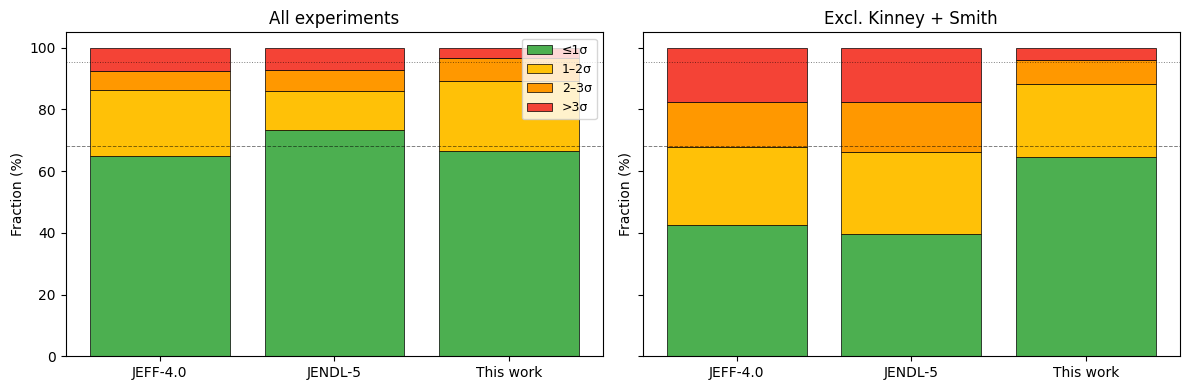

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

band_colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
band_labels = ['≤1σ', '1–2σ', '2–3σ', '>3σ']

for ax, (tbl, title) in zip(axes, [
    (tbl_all, 'All experiments'),
    (tbl_oos, 'Excl. Kinney + Smith'),
]):
    tbl_libs = tbl[tbl['Library'] != 'Gaussian expect.'].copy()
    x = np.arange(len(tbl_libs))
    bottoms = np.zeros(len(tbl_libs))
    pct_cols = ['≤1σ (%)', '1–2σ (%)', '2–3σ (%)', '>3σ (%)']
    for col, color, lbl in zip(pct_cols, band_colors, band_labels):
        vals = tbl_libs[col].astype(float).values
        ax.bar(x, vals, bottom=bottoms, color=color, edgecolor='k',
               linewidth=0.5, label=lbl)
        bottoms += vals
    ax.set_xticks(x)
    ax.set_xticklabels(tbl_libs['Library'].values)
    ax.set_ylabel('Fraction (%)')
    ax.set_title(title)
    # Gaussian reference lines
    ax.axhline(68.27, color='k', ls='--', lw=0.7, alpha=0.5)
    ax.axhline(68.27 + 27.18, color='k', ls=':', lw=0.7, alpha=0.5)

axes[0].legend(loc='upper right', fontsize=9)
fig.tight_layout()
plt.show()

## Breakdown of >2σ outliers by experiment

In [5]:
def outlier_breakdown_by_experiment(df_in, threshold=2, label=''):
    """Per (library, experiment), show how many points exceed the threshold."""
    records = []
    for lib in LIBRARIES:
        sub = df_in[df_in['library'] == lib]
        for (exp_id, author), grp in sub.groupby(['experiment_id', 'author']):
            n_total = len(grp)
            outliers = grp[grp['n_sigma'] > threshold]
            n_out = len(outliers)
            if n_out == 0:
                continue
            n_gt3 = (grp['n_sigma'] > 3).sum()
            records.append({
                'Library': LIB_LABELS[lib],
                'Experiment': exp_id,
                'Author': author,
                'N_total': n_total,
                f'>{threshold}σ': n_out,
                f'>{threshold}σ (%)': 100 * n_out / n_total,
                '>3σ': n_gt3,
                'E_min (MeV)': outliers['energy_mev'].min(),
                'E_max (MeV)': outliers['energy_mev'].max(),
            })
    result = pd.DataFrame(records)
    if len(result) == 0:
        print("No outliers found.")
        return result
    result = result.sort_values(f'>{threshold}σ', ascending=False)
    if label:
        print(f"\n{label}")
        print('—' * len(label))
    with pd.option_context('display.max_rows', None, 'display.float_format', '{:.1f}'.format):
        print(result.to_string(index=False))
    return result


# All experiments
out_all = outlier_breakdown_by_experiment(
    df, threshold=2, label='Outlier breakdown (>2σ) — All experiments')

# Excl. Kinney + Smith
out_oos = outlier_breakdown_by_experiment(
    df[~ks_mask], threshold=2, label='Outlier breakdown (>2σ) — Excl. Kinney + Smith')


Outlier breakdown (>2σ) — All experiments
—————————————————————————————————————————
  Library Experiment     Author  N_total  >2σ  >2σ (%)  >3σ  E_min (MeV)  E_max (MeV)
  JENDL-5   20743002  Cierjacks     4901 1937     39.5  875          0.8          3.0
 JEFF-4.0   20743002  Cierjacks     4901 1760     35.9  895          0.8          3.0
This work   10571002     Kinney    13208 1351     10.2  392          0.8          2.5
This work   20743002  Cierjacks     4901  582     11.9  166          0.9          3.0
 JEFF-4.0   27673002  G. Gkatis      816  290     35.5  178          1.0          4.0
  JENDL-5   27673002  G. Gkatis      800  245     30.6  147          1.0          3.9
  JENDL-5   30076004    Barnard      249  171     68.7  135          0.9          1.2
  JENDL-5   11519016        Cox      368  170     46.2   96          0.9          1.2
 JEFF-4.0   11519016        Cox      368  153     41.6   90          0.9          1.2
 JEFF-4.0   30076004    Barnard      249  133     53.4 

## Outlier concentration by energy bin


All experiments
———————————————

Outlier count per energy bin:
               JEFF-4.0  JENDL-5  This work
e_bin                                      
(0.85, 1.165]       875      943        753
(1.165, 1.48]       594      727        493
(1.48, 1.795]       374      464        392
(1.795, 2.11]       547      517        367
(2.11, 2.425]       432      414        319
(2.425, 2.74]       159      106        108
(2.74, 3.055]        70       33         38
(3.055, 3.37]        29       23          9
(3.37, 3.685]        25       13          3
(3.685, 4.0]         34       13         10

Outlier fraction (%) per energy bin:
               JEFF-4.0  JENDL-5  This work
e_bin                                      
(0.85, 1.165]      17.6     18.9       15.1
(1.165, 1.48]      14.0     17.2       11.6
(1.48, 1.795]       9.7     12.0       10.1
(1.795, 2.11]      14.6     13.8        9.8
(2.11, 2.425]      12.3     11.8        9.1
(2.425, 2.74]      12.9      8.6        8.8
(2.74, 3.055]     

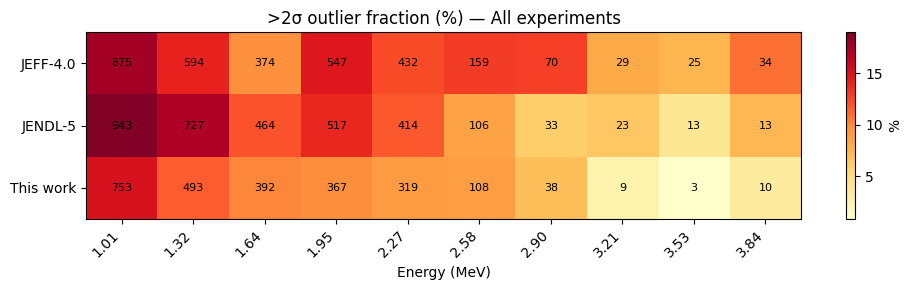


Excl. Kinney + Smith
————————————————————

Outlier count per energy bin:
               JEFF-4.0  JENDL-5  This work
e_bin                                      
(0.85, 1.165]       875      916        430
(1.165, 1.48]       594      716        237
(1.48, 1.795]       368      453        153
(1.795, 2.11]       503      485        115
(2.11, 2.425]       381      386         82
(2.425, 2.74]       146      100         39
(2.74, 3.055]        70       33         34
(3.055, 3.37]        29       23          3
(3.37, 3.685]        25       13          2
(3.685, 4.0]         34       13          9

Outlier fraction (%) per energy bin:
               JEFF-4.0  JENDL-5  This work
e_bin                                      
(0.85, 1.165]      35.6     37.2       17.5
(1.165, 1.48]      34.6     41.7       13.8
(1.48, 1.795]      28.0     34.5       11.6
(1.795, 2.11]      44.3     42.7       10.1
(2.11, 2.425]      40.4     40.9        8.7
(2.425, 2.74]      25.7     17.6        6.9
(2.74, 3

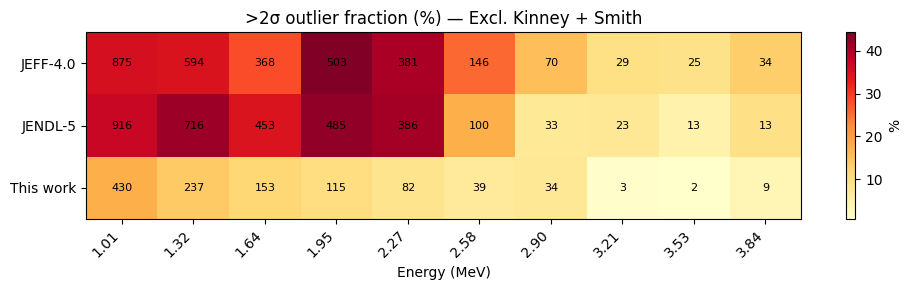

In [6]:
def outlier_energy_heatmap(df_in, threshold=2, label=''):
    """Heatmap: fraction of >threshold-sigma points per energy bin and library."""
    bin_edges = np.linspace(E_MIN, E_MAX, N_ENERGY_BINS + 1)
    df_tmp = df_in.copy()
    df_tmp['e_bin'] = pd.cut(df_tmp['energy_mev'], bins=bin_edges)

    pivot_pct = []
    pivot_count = []
    for lib in LIBRARIES:
        sub = df_tmp[df_tmp['library'] == lib]
        total_per_bin = sub.groupby('e_bin', observed=False).size()
        outlier_per_bin = sub[sub['n_sigma'] > threshold].groupby('e_bin', observed=False).size()
        pct = 100 * outlier_per_bin / total_per_bin
        pivot_pct.append(pct.rename(LIB_LABELS[lib]))
        pivot_count.append(outlier_per_bin.rename(LIB_LABELS[lib]))

    pct_df = pd.concat(pivot_pct, axis=1).fillna(0)
    count_df = pd.concat(pivot_count, axis=1).fillna(0).astype(int)

    # Print table
    if label:
        print(f"\n{label}")
        print('—' * len(label))
    print("\nOutlier count per energy bin:")
    print(count_df.to_string())
    print("\nOutlier fraction (%) per energy bin:")
    with pd.option_context('display.float_format', '{:.1f}'.format):
        print(pct_df.to_string())

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 3))
    im = ax.imshow(pct_df.values.T, aspect='auto', cmap='YlOrRd')
    ax.set_yticks(range(len(LIBRARIES)))
    ax.set_yticklabels([LIB_LABELS[l] for l in LIBRARIES])
    bin_labels = [f'{e:.2f}' for e in (bin_edges[:-1] + bin_edges[1:]) / 2]
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45, ha='right')
    ax.set_xlabel('Energy (MeV)')
    ax.set_title(f'>{threshold}σ outlier fraction (%){" — " + label if label else ""}')
    plt.colorbar(im, ax=ax, label='%')
    # Annotate cells with counts
    for i in range(pct_df.shape[0]):
        for j in range(pct_df.shape[1]):
            count_val = count_df.iloc[i, j]
            if count_val > 0:
                ax.text(i, j, str(count_val), ha='center', va='center', fontsize=8)
    fig.tight_layout()
    plt.show()

    return pct_df, count_df


pct_all, cnt_all = outlier_energy_heatmap(
    df, threshold=2, label='All experiments')

pct_oos, cnt_oos = outlier_energy_heatmap(
    df[~ks_mask], threshold=2, label='Excl. Kinney + Smith')

## Scatter: outlier points on (energy, μ) plane

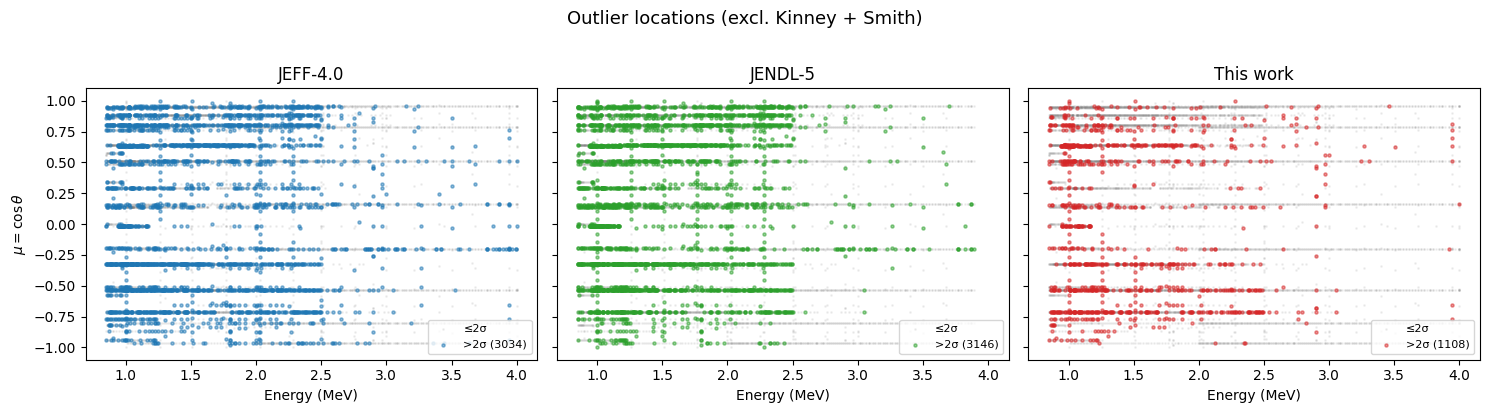

In [7]:
fig, axes = plt.subplots(1, len(LIBRARIES), figsize=(5 * len(LIBRARIES), 4),
                         sharey=True, sharex=True)
if len(LIBRARIES) == 1:
    axes = [axes]

for ax, lib in zip(axes, LIBRARIES):
    sub = df[(df['library'] == lib) & (~ks_mask)]
    ok = sub[sub['n_sigma'] <= 2]
    bad = sub[sub['n_sigma'] > 2]
    ax.scatter(ok['energy_mev'], ok['mu'], s=1, alpha=0.1, color='gray',
               rasterized=True, label='≤2σ')
    ax.scatter(bad['energy_mev'], bad['mu'], s=5, alpha=0.5,
               color=LIB_COLORS[lib], rasterized=True, label=f'>2σ ({len(bad)})')
    ax.set_title(LIB_LABELS[lib])
    ax.set_xlabel('Energy (MeV)')
    ax.legend(fontsize=8, loc='lower right')

axes[0].set_ylabel(r'$\mu = \cos\theta$')
fig.suptitle('Outlier locations (excl. Kinney + Smith)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## Results and discussion

### Which comparison matters more: with or without Kinney and Smith?

Both views are informative, but they answer different questions.

**Including Kinney and Smith** tests whether the evaluations reproduce the data they were built from.
JEFF-4.0 and JENDL-5 were calibrated to these two experiments, so good agreement here is expected
and simply confirms that the fitting procedure worked. Their combined 41,084 points (59% of the
dataset) dominate the statistics and mask problems with other experiments. In this view all three
libraries look reasonable: 65--74% of points within 1$\sigma$, close to the Gaussian expectation of 68%.

**Excluding Kinney and Smith** removes the calibration data for JEFF and JENDL, exposing how well
they predict measurements they were not fitted to. This is where the libraries diverge:

| | $\leq 1\sigma$ | $>2\sigma$ | $>3\sigma$ |
|---|---|---|---|
| JEFF-4.0 | 43.5% | 30.7% | 16.5% |
| JENDL-5 | 41.0% | 32.6% | 16.5% |
| This work | 66.2% | 10.8% | 3.7% |
| Gaussian | 68.3% | 4.6% | 0.3% |

JEFF-4.0 and JENDL-5 drop to ~42% within 1$\sigma$ and place roughly a third of all independent
data beyond 2$\sigma$. Their >3$\sigma$ tails (16.5%) are 60 times the Gaussian expectation of 0.27%.

### Important caveat: this work is not out-of-sample either

The comparison above is **not symmetric**. Excluding Kinney and Smith creates a genuine
out-of-sample test for JEFF-4.0 and JENDL-5, because those libraries were calibrated exclusively
to those two experiments. However, this work was fitted using *all* available experimental data,
including Cierjacks, Gkatis, Pirovano, and the other experiments in the "excl. Kinney+Smith"
subset. The good coverage of this work on that subset is therefore partly expected — it is
reproducing data it was trained on.

A truly fair out-of-sample test for this work would require a leave-out cross-validation,
which is not performed here.

What the comparison *does* show is the consequence of different calibration strategies:

- **JEFF/JENDL approach**: calibrate to 2 dense, high-quality experiments (Kinney, Smith) →
  excellent reproduction of those datasets, but poor generalization to other measurements.
- **This work**: calibrate to all available experiments → broader consistency across the
  experimental landscape, at the cost of not being independently validated.

The practical advantage of the broader calibration base is that the evaluation is less vulnerable
to the systematic biases of any single experiment. But the good sigma-band coverage of this work
should be interpreted as a consistency check (the fit reproduces its own input data with
realistic uncertainties), not as a demonstration of predictive power on unseen data.

### Are the covariances well calibrated?

For a perfectly calibrated evaluation with Gaussian residuals, one expects 68.3% of points within
1$\sigma$, 95.4% within 2$\sigma$, and 99.7% within 3$\sigma$.

Regardless of the in-sample vs. out-of-sample distinction, the sigma-band coverage provides a
useful check on whether the **reported covariance matrices (MF34)** are realistic.

For JEFF-4.0 and JENDL-5, even on the full dataset (including their calibration data), the >3$\sigma$
tails are 7% — 26 times the Gaussian expectation. This indicates that their MF34 covariance
matrices underestimate the true uncertainty even for data they were fitted to.

This work shows 3.2% beyond 3$\sigma$ on the full dataset and 3.7% on the subset excluding
Kinney and Smith. While still above the Gaussian expectation of 0.27%, this is consistent with
the heavier-than-Gaussian tails that are common in nuclear data, where systematic effects and
unresolved resonance structure create non-Gaussian residual distributions.

### Which experiments drive the disagreement?

The outlier breakdown identifies the main sources of tension (excluding Kinney and Smith):

1. **Cierjacks (20743002)** — by far the largest contributor. For JEFF and JENDL, 35--39% of its
   4,901 points exceed 2$\sigma$ (with ~860 beyond 3$\sigma$). Even for this work, 11% of Cierjacks
   points are outliers — a reminder that even with broad calibration, this dense and precise
   experiment exposes shape differences. The tension spans 0.8--3.0 MeV.

2. **Gkatis (27673002)** — 816 points, 28% outliers for JEFF, 23% for JENDL, but only 5.8% for
   this work. Covers 1.0--4.0 MeV.

3. **Barnard (30076004)** and **Cox (11519016)** — older experiments near 0.9--1.2 MeV with high
   outlier rates across all libraries (20--69%). These may have systematic issues or reflect
   genuine difficulty in the ~1 MeV region where resonance structure complicates angular
   distributions.

4. **Jacquot (20379003)** and **Malmskog (20197006)** — 50--58% outlier rates for JEFF and JENDL,
   30--32% for this work. Both are older experiments in the 0.8--2.3 MeV range.

5. **Pirovano (23365004/005)** — recent high-quality data at 2.0--4.0 MeV. All libraries agree
   well: only 5--7% outlier rates for JEFF and JENDL, and <1% for this work. This is
   encouraging because Pirovano data has well-characterized uncertainties.

### Energy dependence of outliers

The energy-bin breakdown (excl. Kinney and Smith) shows that outlier concentration is
strongly energy-dependent:

- **0.85--2.4 MeV**: JEFF and JENDL have 30--42% outlier fractions; this work has 8--17%.
  This is the region most densely covered by Kinney, whose systematics dominate the JEFF/JENDL
  calibration.
- **2.7--4.0 MeV**: all libraries improve, with JEFF/JENDL dropping to 6--13% and this work
  to 0.3--5%. Fewer experiments here, and those that exist (Pirovano, Smith) are more consistent
  across libraries.

### Summary

- **Including Kinney and Smith**: all libraries show reasonable coverage (~65--74% within 1$\sigma$),
  confirming that each evaluation reproduces its own calibration data.
- **Excluding Kinney and Smith**: JEFF-4.0 and JENDL-5 drop to ~42% within 1$\sigma$, revealing
  poor generalization beyond their calibration base. This work maintains 66% coverage, but this
  is expected since it was calibrated on those experiments.
- The main conclusion is about **calibration strategy**: fitting to a broader experimental base
  produces an evaluation that is more consistent across the full range of available measurements,
  even though this does not constitute a true out-of-sample validation.
- The MF34 covariances of JEFF-4.0 and JENDL-5 underestimate uncertainty even on in-sample data
  (7% beyond 3$\sigma$ with all experiments included). This work's covariances are closer to
  realistic, though still showing heavier tails than a Gaussian distribution.
- The largest source of tension across all libraries is the Cierjacks experiment, whose dense
  angular coverage and small reported uncertainties expose shape differences at the sub-percent level.
- Modern experiments (Pirovano) show good agreement for all three evaluations.